### CCS 249 – Natural Language Processing

**Student:** Ginno D. Arostique Jr.  

**Course:** BSCS 3B - AI 

**Date:** April 10, 2026 

---

# Exercise 5 For Unit 5

In [1]:
# Core imports
import re
import random
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Corpus selection
WIKI_URL = "https://en.wikipedia.org/wiki/Bleach_(manga)"


# Baseline Word2Vec parameters
BASE_VECTOR_SIZE = 100
BASE_WINDOW = 5

### Utility Functions

In [2]:
def ensure_nltk_resources() -> None:
    """Download tokenizer resources if missing."""
    resources = ["punkt", "punkt_tab"]
    for resource in resources:
        try:
            nltk.data.find(f"tokenizers/{resource}")
        except LookupError:
            nltk.download(resource)


def fetch_wikipedia_article(url: str) -> str:
    """Fetch visible article text from a Wikipedia page."""
    headers = {"User-Agent": "Mozilla/5.0 (compatible; Exercise5-SGNS/1.0)"}
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not locate Wikipedia article content.")

    # Pull text from paragraphs and list items to maximize usable corpus size.
    blocks = []
    for tag in content_div.find_all(["p", "li"]):
        text = tag.get_text(" ", strip=True)
        if text:
            blocks.append(text)

    article_text = "\n".join(blocks)

    # Clean references like [12] and normalize whitespace.
    article_text = re.sub(r"\[[0-9]+\]", " ", article_text)
    article_text = re.sub(r"\s+", " ", article_text).strip()
    return article_text

### Text Processing Utilities

In [3]:
def preprocess_text(text: str, min_token_len: int = 2) -> List[List[str]]:
    """Sentence tokenize, normalize, and return tokenized sentences."""
    sentences = sent_tokenize(text)
    processed_sentences: List[List[str]] = []

    for sentence in sentences:
        sentence = sentence.lower()
        sentence = re.sub(r"[^a-z0-9\-\s]", " ", sentence)
        sentence = re.sub(r"\s+", " ", sentence).strip()
        if not sentence:
            continue

        tokens = word_tokenize(sentence)
        cleaned_tokens = []

        for token in tokens:
            token = token.strip("-")
            if not token:
                continue
            if token.isdigit():
                continue
            if len(token) < min_token_len:
                continue
            cleaned_tokens.append(token)

        if len(cleaned_tokens) >= 3:
            processed_sentences.append(cleaned_tokens)

    return processed_sentences


def corpus_stats(tokenized_sentences: List[List[str]]) -> Dict[str, int]:
    flat_tokens = [token for sentence in tokenized_sentences for token in sentence]
    vocab = set(flat_tokens)
    return {
        "num_sentences": len(tokenized_sentences),
        "num_tokens": len(flat_tokens),
        "vocab_size": len(vocab),
    }

### Model Training Utilities

In [4]:
def train_skipgram_model(
    tokenized_sentences: List[List[str]],
    vector_size: int = 100,
    window: int = 5,
    epochs: int = 150,
    negative: int = 10,
    min_count: int = 1,
) -> Word2Vec:
    """Train Word2Vec using Skip-gram (sg=1) with Negative Sampling."""
    model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4,
        sg=1,
        negative=negative,
        epochs=epochs,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model


def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine_sim(model: Word2Vec, word_a: str, word_b: str) -> float:
    vec_a = model.wv[word_a].reshape(1, -1)
    vec_b = model.wv[word_b].reshape(1, -1)
    return float(cosine_similarity(vec_a, vec_b)[0][0])


def nearest_neighbors(model: Word2Vec, word: str, topn: int = 8):
    if not has_word(model, word):
        return []
    return model.wv.most_similar(word, topn=topn)

### Evaluation Utilities

In [5]:
def evaluate_relatedness(
    model: Word2Vec,
    test_pairs: List[Tuple[str, str, float]],
) -> Dict[str, object]:
    records = []
    gold_scores = []
    predicted_scores = []

    for word_a, word_b, gold in test_pairs:
        if has_word(model, word_a) and has_word(model, word_b):
            pred = cosine_sim(model, word_a, word_b)
            records.append((word_a, word_b, gold, pred))
            gold_scores.append(gold)
            predicted_scores.append(pred)

    # Pearson correlation gives a compact test-set performance indicator.
    if len(gold_scores) >= 2:
        pearson = float(np.corrcoef(gold_scores, predicted_scores)[0, 1])
    else:
        pearson = float("nan")

    return {
        "records": records,
        "coverage": len(records),
        "total": len(test_pairs),
        "pearson": pearson,
    }


def evaluate_analogies(
    model: Word2Vec,
    analogy_set: List[Tuple[str, str, str, str]],
    topn: int = 5,
) -> Dict[str, object]:
    covered = 0
    correct = 0
    details = []

    for a, b, c, expected in analogy_set:
        if all(has_word(model, w) for w in [a, b, c, expected]):
            covered += 1
            preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=topn)
            predicted_words = [w for w, _ in preds]
            is_hit = expected in predicted_words
            correct += int(is_hit)
            details.append(
                {
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": expected,
                    "predictions": predicted_words,
                    "correct_in_topn": is_hit,
                }
            )

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogy_set),
        "accuracy_topn": accuracy,
        "details": details,
    }


def evaluation_summary(
    model: Word2Vec,
    relatedness_set: List[Tuple[str, str, float]],
    analogy_set: List[Tuple[str, str, str, str]],
) -> Dict[str, object]:
    relatedness = evaluate_relatedness(model, relatedness_set)
    analogies = evaluate_analogies(model, analogy_set, topn=5)

    return {
        "relatedness_coverage": relatedness["coverage"],
        "relatedness_total": relatedness["total"],
        "relatedness_pearson": relatedness["pearson"],
        "analogy_coverage": analogies["coverage"],
        "analogy_total": analogies["total"],
        "analogy_accuracy_top5": analogies["accuracy_topn"],
    }

## Baseline Training and Evaluation (Window Size = 5)

In [6]:
ensure_nltk_resources()

print("Downloading corpus from:", WIKI_URL)
raw_text = fetch_wikipedia_article(WIKI_URL)

# Preprocess the text coming from the selected corpus.
print("Preprocessing corpus...")
tokenized_sentences = preprocess_text(raw_text)
stats = corpus_stats(tokenized_sentences)

print("\n=== Corpus Statistics ===")
for key, value in stats.items():
    print(f"{key}: {value}")


# Domain-focused probe words for nearest-neighbor inspection.
probe_words = [
    "bleach", "ichigo", "rukia", "orihime", "uryu", "chad", "renji", "aizen",
    "shinigami", "hollow", "arrancar", "quincy", "soul", "society", "captain",
    "bankai", "zanpakuto", "karakura", "anime", "manga",
]


# Small intrinsic test set: expected semantic relatedness (0 to 1 scale).
relatedness_test = [
    ("bleach", "ichigo", 0.95),
    ("bleach", "rukia", 0.90),
    ("shinigami", "captain", 0.80),
    ("soul", "society", 0.95),
    ("bankai", "zanpakuto", 0.90),
    ("quincy", "uryu", 0.88),
    ("arrancar", "hollow", 0.86),
    ("karakura", "town", 0.70),
    ("anime", "manga", 0.82),
    ("bleach", "kitchen", 0.05),
    ("captain", "school", 0.15),
    ("shinigami", "guitar", 0.03),
]


# Small analogy set; performance depends on corpus size and vocabulary coverage.
analogy_test = [
    ("captain", "shinigami", "quincy", "uryu"),
    ("ichigo", "human", "rukia", "shinigami"),
    ("bleach", "manga", "anime", "series"),
    ("karakura", "town", "soul", "society"),
]

Preprocessing corpus...

=== Corpus Statistics ===
num_sentences: 566
num_tokens: 6440
vocab_size: 1764


### Train Baseline Model

In [7]:
print("\nTraining baseline SGNS model (window=5)...")

# Train a Skip-gram with Negative Sampling model
model_w5 = train_skipgram_model(
    tokenized_sentences=tokenized_sentences,
    vector_size=BASE_VECTOR_SIZE,
    window=BASE_WINDOW,
    epochs=150,
    negative=10,
    min_count=1,
)

print("Vocabulary size learned:", len(model_w5.wv))


Training baseline SGNS model (window=5)...
Vocabulary size learned: 1764


### Baseline Nearest-Neighbor Report

In [8]:
print("\n=== Nearest Neighbors ===")
for word in probe_words:
    neighbors = nearest_neighbors(model_w5, word, topn=8)
    if not neighbors:
        print(f"\n{word}: [OOV]")
        continue

    print(f"\n{word}:")
    for neighbor_word, score in neighbors:
        print(f"  {neighbor_word:20s} {score:.4f}")


=== Nearest Neighbors ===

bleach:
  artbook              0.4391
  rules                0.4324
  karaburi             0.4293
  faq                  0.4281
  vol                  0.4261
  line                 0.4164
  smartphone           0.4122
  bootleg              0.4066

ichigo:
  kurosaki             0.5936
  allies               0.5833
  trust                0.5829
  reaffirms            0.5673
  join                 0.5620
  falls                0.5534
  defeats              0.5520
  suspicion            0.5473

rukia:
  kuchiki              0.8023
  apprehends           0.7565
  freedom              0.7552
  encounter            0.7549
  command              0.7547
  assumes              0.7531
  exposes              0.7426
  secures              0.7394

orihime:
  backstory            0.8611
  example              0.8486
  retrieves            0.8482
  help                 0.8351
  abducts              0.8304
  marry                0.8256
  classmate            0.8251
  attac

### Baseline Test-Set Evaluation and Model Save

In [9]:
# Report nearest neighbors, similarity scores, and test-set performance.
relatedness_results_w5 = evaluate_relatedness(model_w5, relatedness_test)
print("\n=== Relatedness Evaluation ===")
print(
    f"Coverage: {relatedness_results_w5['coverage']}/{relatedness_results_w5['total']} | "
    f"Pearson: {relatedness_results_w5['pearson']:.4f}"
)
records = relatedness_results_w5.get("records", [])
if isinstance(records, list):
    for word_a, word_b, gold, pred in records:
        print(f"{word_a:12s} - {word_b:12s} | gold={gold:.2f} pred={pred:.4f}")
else:
    print("No relatedness records available.")


analogy_results_w5 = evaluate_analogies(model_w5, analogy_test, topn=5)
print("\n=== Analogy Evaluation ===")
print(
    f"Coverage: {analogy_results_w5['coverage']}/{analogy_results_w5['total']} | "
    f"Top-5 Accuracy: {analogy_results_w5['accuracy_topn']:.4f}"
)
details = analogy_results_w5.get("details", [])
if isinstance(details, list):
    for item in details:
        print(item)
else:
    print("No analogy details available.")


baseline_summary = evaluation_summary(model_w5, relatedness_test, analogy_test)
print("\n=== Baseline Summary (window=5) ===")
print(pd.DataFrame([baseline_summary]))


# Save baseline model for reproducibility.
model_w5.save("exercise_5_skipgram_sgns_w5.model")
print("\nSaved baseline model to: exercise_5_skipgram_sgns_w5.model")


=== Relatedness Evaluation ===
Coverage: 8/12 | Pearson: -0.1334
bleach       - ichigo       | gold=0.95 pred=0.1047
bleach       - rukia        | gold=0.90 pred=0.0598
shinigami    - captain      | gold=0.80 pred=0.3464
soul         - society      | gold=0.95 pred=0.5777
arrancar     - hollow       | gold=0.86 pred=0.3780
karakura     - town         | gold=0.70 pred=0.9460
anime        - manga        | gold=0.82 pred=0.3250
captain      - school       | gold=0.15 pred=0.3305

=== Analogy Evaluation ===
Coverage: 3/4 | Top-5 Accuracy: 0.0000
{'analogy': 'ichigo:human::rukia:?', 'expected': 'shinigami', 'predictions': ['sentences', 'execution', 'body', 'temporary', 'recuperates'], 'correct_in_topn': False}
{'analogy': 'bleach:manga::anime:?', 'expected': 'series', 'predictions': ['footsteps', 'winners', 'adapts', 'theme', 'sequel'], 'correct_in_topn': False}
{'analogy': 'karakura:town::soul:?', 'expected': 'society', 'predictions': ['reapers', 'surveillance', 'suppression', 'restore', 


Question:

1. What are the critical parts of the script related on training the Word2Vec?

Answer:

The most critical parts of the script are the data pipeline, the training configuration, and the reproducibility setup.

First, the data pipeline determines embedding quality before training even starts. The script downloads raw text from a Wikipedia page, extracts visible content, removes noise such as citation markers, and normalizes whitespace. After that, it tokenizes text into sentences and words, lowercases tokens, removes punctuation and numeric-only tokens, filters very short tokens, and keeps only sentences with enough valid tokens. This process is essential because Word2Vec learns from local co-occurrence patterns, so cleaner and more consistent context leads to more meaningful vectors.

Second, the training configuration in the model function is central to how semantic structure is learned. The model uses Skip-gram through sg=1, which is effective for learning informative representations, especially for less frequent words. It also uses negative sampling through negative=10 to make training efficient while improving discrimination between related and unrelated terms. Core hyperparameters such as vector_size and window control representation capacity and context span, while min_count determines vocabulary inclusion and epochs controls how thoroughly patterns are learned. Learning-rate settings and subsampling also influence stability and generalization.

Third, reproducibility settings make results dependable. The script fixes random seeds so model behavior is more consistent across runs, making comparisons between experiments like window=5 versus window=10 more trustworthy.

Overall, training quality comes from the combination of strong preprocessing, well-chosen SGNS hyperparameters, and controlled experiment settings. If any of these parts are weak, embedding quality and evaluation reliability will drop.

Question:

2. What Word2Vec methods were used to evaluate the similarity of words?

Answer:

The code uses multiple evaluation methods that together provide both qualitative and quantitative evidence of embedding quality.

Nearest-neighbor similarity using most_similar. This is used through the nearest_neighbors helper to inspect which words are closest to a target word in vector space. It gives a quick qualitative check of whether semantic neighborhoods are sensible (for example, whether character names and related terms cluster together).

Pairwise cosine similarity for controlled word pairs.
The script directly computes cosine similarity between selected word pairs using word vectors and cosine_similarity. This produces numeric similarity scores and allows comparison against expected relatedness levels for known pairs.

Relatedness test-set scoring with correlation.
Beyond individual pair scores, the script compares predicted similarities with gold relatedness scores and computes Pearson correlation. This summarizes how well model similarity aligns with expected semantic relatedness across the test set.

Analogy evaluation using vector arithmetic.
The script applies analogy queries with positive and negative word sets, then checks whether the expected answer appears in the top predictions. This tests relational semantics (for example, whether learned vectors preserve meaningful word relationships, not just direct similarity).

Coverage reporting.
The evaluation also reports how many test items are actually evaluable based on vocabulary presence. This is important because out-of-vocabulary terms can otherwise make results look better or worse than they really are.

Together, these methods assess local neighborhood quality, numeric similarity behavior, relational reasoning, and test validity. This combination gives a more complete view of Word2Vec performance than relying on a single metric.

## Retrain with Window Size = 10

In [10]:
print("Training second SGNS model (window=10)...")
model_w10 = train_skipgram_model(
    tokenized_sentences=tokenized_sentences,
    vector_size=BASE_VECTOR_SIZE,
    window=10,
    epochs=150,
    negative=10,
    min_count=1,
)

summary_w10 = evaluation_summary(model_w10, relatedness_test, analogy_test)
print("\n=== New Summary (window=10) ===")
print(pd.DataFrame([summary_w10]))

comparison_df = pd.DataFrame(
    [
        {"model": "window_5", **baseline_summary},
        {"model": "window_10", **summary_w10},
    ]
)

print("\n=== Comparison: Window 5 vs Window 10 ===")
print(comparison_df)

Training second SGNS model (window=10)...

=== New Summary (window=10) ===
   relatedness_coverage  relatedness_total  relatedness_pearson  \
0                     8                 12            -0.084747   

   analogy_coverage  analogy_total  analogy_accuracy_top5  
0                 3              4                    0.0  

=== Comparison: Window 5 vs Window 10 ===
       model  relatedness_coverage  relatedness_total  relatedness_pearson  \
0   window_5                     8                 12            -0.133359   
1  window_10                     8                 12            -0.084747   

   analogy_coverage  analogy_total  analogy_accuracy_top5  
0                 3              4                    0.0  
1                 3              4                    0.0  


### Window-10 Detailed Outputs and Save

Print pair-level details and save the second model.

In [11]:
relatedness_results_w10 = evaluate_relatedness(model_w10, relatedness_test)
analogy_results_w10 = evaluate_analogies(model_w10, analogy_test, topn=5)

print("\nRelatedness details (window=10):")
records_w10 = relatedness_results_w10.get("records", [])
if isinstance(records_w10, list):
    for word_a, word_b, gold, pred in records_w10:
        print(f"{word_a:12s} - {word_b:12s} | gold={gold:.2f} pred={pred:.4f}")
else:
    print("No relatedness records available.")

print("\nAnalogy details (window=10):")
details_w10 = analogy_results_w10.get("details", [])
if isinstance(details_w10, list):
    for item in details_w10:
        print(item)
else:
    print("No analogy details available.")

model_w10.save("exercise_5_skipgram_sgns_w10.model")
print("\nSaved second model to: exercise_5_skipgram_sgns_w10.model")


Relatedness details (window=10):
bleach       - ichigo       | gold=0.95 pred=0.1486
bleach       - rukia        | gold=0.90 pred=0.0380
shinigami    - captain      | gold=0.80 pred=0.3628
soul         - society      | gold=0.95 pred=0.6083
arrancar     - hollow       | gold=0.86 pred=0.3123
karakura     - town         | gold=0.70 pred=0.9447
anime        - manga        | gold=0.82 pred=0.3077
captain      - school       | gold=0.15 pred=0.2980

Analogy details (window=10):
{'analogy': 'ichigo:human::rukia:?', 'expected': 'shinigami', 'predictions': ['sentences', 'execution', 'bestowing', 'unlawfully', 'temporary'], 'correct_in_topn': False}
{'analogy': 'bleach:manga::anime:?', 'expected': 'series', 'predictions': ['adapts', 'sequel', 'winners', 'finalists', 'awards'], 'correct_in_topn': False}
{'analogy': 'karakura:town::soul:?', 'expected': 'society', 'predictions': ['reapers', 'surveillance', 'suppression', 'reaper', 'betrayal'], 'correct_in_topn': False}

Saved second model to: ex

Observation:

Old: The baseline model with window size 5 learns from a narrower context, so each target word is mainly influenced by nearby words. Because of this, it often captures strong short-range associations, such as names, titles, and terms that repeatedly appear together within the same phrase or sentence segment. In this corpus, that can help preserve tight links between specific Bleach entities and their immediately surrounding descriptors. However, the smaller window can miss broader narrative or thematic signals that are spread across longer spans of text, so some concept-level relationships may be weaker.

New: The retrained model with window size 10 uses a wider context, allowing each word to learn from a larger neighborhood. This generally helps the model represent higher-level themes and long-range co-occurrence structure, which can improve relationships between words that are semantically related but not always adjacent. In exchange, the broader context may slightly reduce the sharpness of very local pairings, since more surrounding words contribute to each update. The comparison table (relatedness Pearson score, analogy top-5 accuracy, and coverage) is therefore important: if window 10 improves correlation and analogy performance without harming coverage, it suggests better global semantics; if window 5 performs better, your corpus may benefit more from precise local context.

## PCA Visualization of Word Vectors

In [12]:
def select_plot_words(model: Word2Vec, preferred_words: List[str], min_words: int = 20) -> List[str]:
    """Return at least min_words words, prioritizing domain terms then top vocab words."""
    selected = [word for word in preferred_words if has_word(model, word)]

    if len(selected) < min_words:
        for vocab_word in model.wv.index_to_key:
            if vocab_word and isinstance(vocab_word, str) and vocab_word.isalpha() and vocab_word not in selected:
                selected.append(vocab_word)
            if len(selected) >= min_words:
                break

    return selected


def plot_word_vectors_pca(model: Word2Vec, words: List[str], title: str) -> None:
    vectors = np.array([model.wv[word] for word in words])
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(14, 10))
    plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7)

    for idx, word in enumerate(words):
        plt.annotate(word, (reduced[idx, 0], reduced[idx, 1]), fontsize=9, alpha=0.9)

    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(alpha=0.25)
    plt.show()

### PCA Plot Inputs and Visualization

Number of plotted words: 26
Words used for PCA plot:
['bleach', 'ichigo', 'rukia', 'orihime', 'chad', 'renji', 'aizen', 'byakuya', 'kenpachi', 'ulquiorra', 'shinigami', 'hollow', 'arrancar', 'quincy', 'captain', 'bankai', 'soul', 'society', 'karakura', 'human', 'arc', 'series', 'anime', 'manga', 'chapter', 'battle']


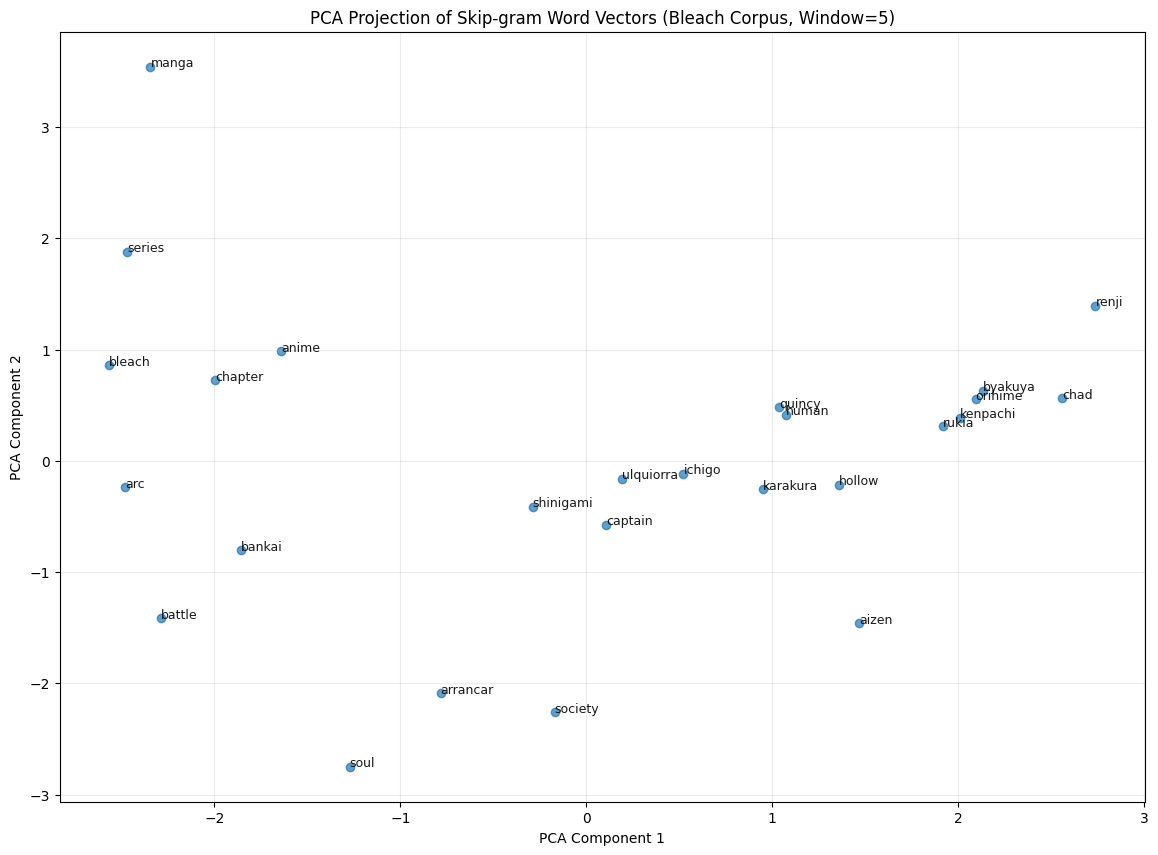

In [13]:
# 20+ known Bleach-related candidates for visualization.
known_bleach_words = [
    "bleach", "ichigo", "rukia", "orihime", "uryu", "chad", "renji", "aizen", "toshiro", "byakuya",
    "kenpachi", "ulquiorra", "grimmjow", "shinigami", "hollow", "arrancar", "quincy", "captain", "bankai", "zanpakuto",
    "soul", "society", "karakura", "human", "arc", "series", "anime", "manga", "chapter", "battle",
]

plot_words = select_plot_words(model_w5, known_bleach_words, min_words=20)
print(f"Number of plotted words: {len(plot_words)}")
print("Words used for PCA plot:")
print(plot_words)

plot_word_vectors_pca(
    model=model_w5,
    words=plot_words,
    title="PCA Projection of Skip-gram Word Vectors (Bleach Corpus, Window=5)",
)